In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-11 17:02:52 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-11 17:02:53 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-11 17:02:53 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-11 17:02:53 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-11 17:02:53 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-11 17:02:54 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-11 17:02:54 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-11 17:02:54 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [3]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.lstm import LSTMForecaster
from src.training.trainer import train_model, predict

lstm_model = LSTMForecaster(num_features=X_train.shape[2])
history = train_model(lstm_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)
print("Retrained LSTM — parameters:", history["num_parameters"], "| time:", round(history["training_time_seconds"], 1), "s")

2026-09-11 17:03:30 | INFO     | src.training.trainer | Training LSTMForecaster | 23576 parameters | device=cpu
2026-09-11 17:03:30 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:04:18 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:04:31 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.049432 | val_loss=0.015300
2026-09-11 17:04:31 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:05:02 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:05:15 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.007187 | val_loss=0.006750
2026-09-11 17:05:15 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:05:48 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:06:02 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.004354 | val_loss=0.005021
2026-09-11 17:06:02 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:06:31 | INFO     | src.training.trainer |   batch 1

In [4]:
from src.evaluation.error_analysis import error_by_horizon_step
from src.preprocessing import inverse_transform_column
from src.config import TARGET_COL

y_pred_test_scaled = predict(lstm_model, X_test)

y_true_full = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_full = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

horizon_errors = error_by_horizon_step(y_true_full, y_pred_full)
print(horizon_errors)

    horizon_step        MAE        RMSE
0              1  61.657020   84.008717
1              2  66.449954   90.420546
2              3  69.306626   95.387983
3              4  68.522247   93.403677
4              5  70.508508   96.428287
5              6  72.602743  100.793624
6              7  73.970749  101.540797
7              8  73.792837  101.509736
8              9  73.439541  100.111550
9             10  71.193534   96.232676
10            11  70.725347   96.659731
11            12  75.478072  100.173809
12            13  75.131545   97.908477
13            14  70.456116   93.373510
14            15  72.617407   96.227855
15            16  71.098558   94.003279
16            17  68.832394   91.763682
17            18  68.423365   90.844923
18            19  68.173274   91.913528
19            20  73.321294   98.563612
20            21  71.727059   96.092622
21            22  73.680420   99.521257
22            23  71.738371   96.089160
23            24  78.894210  104.705766


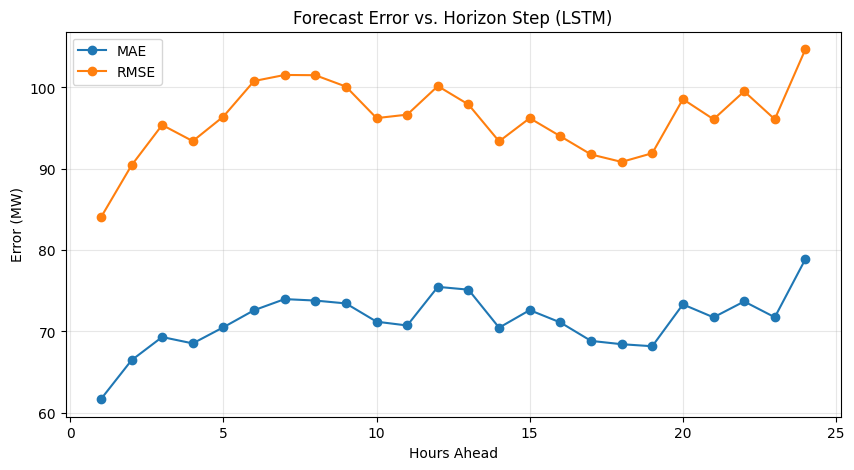

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(horizon_errors["horizon_step"], horizon_errors["MAE"], marker="o", label="MAE")
ax.plot(horizon_errors["horizon_step"], horizon_errors["RMSE"], marker="o", label="RMSE")
ax.set_xlabel("Hours Ahead")
ax.set_ylabel("Error (MW)")
ax.set_title("Forecast Error vs. Horizon Step (LSTM)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [6]:
first_hour_mae = horizon_errors.iloc[0]["MAE"]
last_hour_mae = horizon_errors.iloc[-1]["MAE"]
degradation_pct = (last_hour_mae - first_hour_mae) / first_hour_mae * 100

print(f"Hour+1 MAE: {first_hour_mae:.2f} MW")
print(f"Hour+24 MAE: {last_hour_mae:.2f} MW")
print(f"Degradation: {degradation_pct:.1f}% worse at hour+24 vs hour+1")

Hour+1 MAE: 61.66 MW
Hour+24 MAE: 78.89 MW
Degradation: 28.0% worse at hour+24 vs hour+1


In [7]:
horizon_errors.to_csv(Path.cwd().parent / "experiments" / "horizon_error_analysis.csv", index=False)
print("Saved horizon_error_analysis.csv")

Saved horizon_error_analysis.csv
